In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=8fe3c19f37ad99ab1f8875fbb9c833494e62a055e983f2480433ece929442be1
  Stored in directory: /root/.cache/pip/wheels/d8/05/68/b3e42de5bbb993864ab67e8f03fd15d7c60b9b21f908f545e5
Successfully built tf-nightly-gpu-2.0-preview


2026-02-28 17:10:47.836810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772298648.056311      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772298648.129081      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772298667.424693      20 gpu_device.cc:2022] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772298667.428252      20 gpu_device.cc:2022] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (380, 380),  # EfficientNetB4 expects 380x380
    'batch_size': 16,  # Reduced batch size due to larger image size
    'phase1_epochs': 25,  # Frozen base training
    'phase2_epochs': 15,  # Fine-tuning
    'phase1_learning_rate': 0.001,
    'phase2_learning_rate': 0.00001,  # Lower LR for fine-tuning EfficientNet
    'num_classes': 4,
    'seed': 42,
    'base_model_name': 'EfficientNetB4'
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


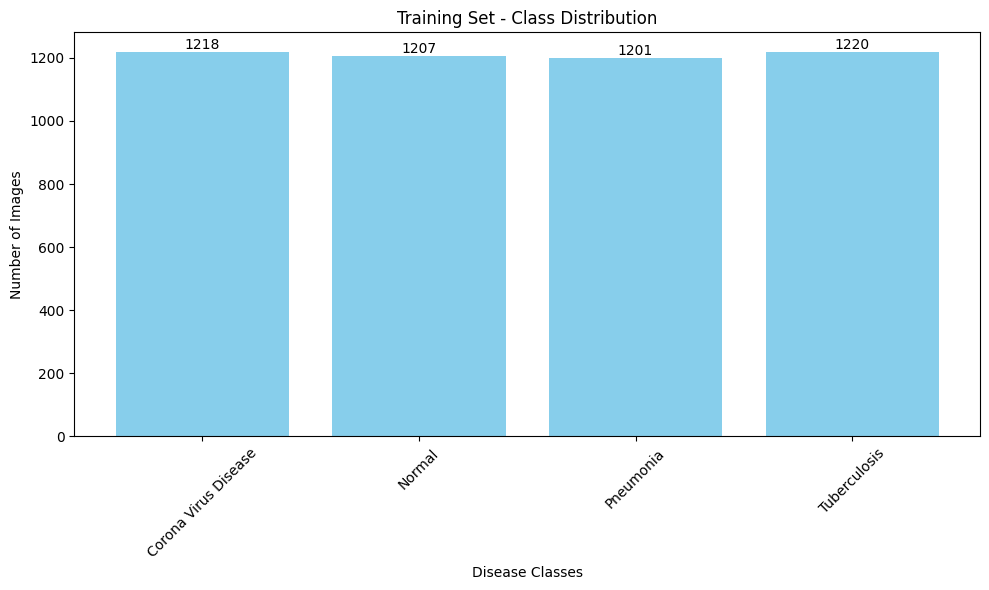


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


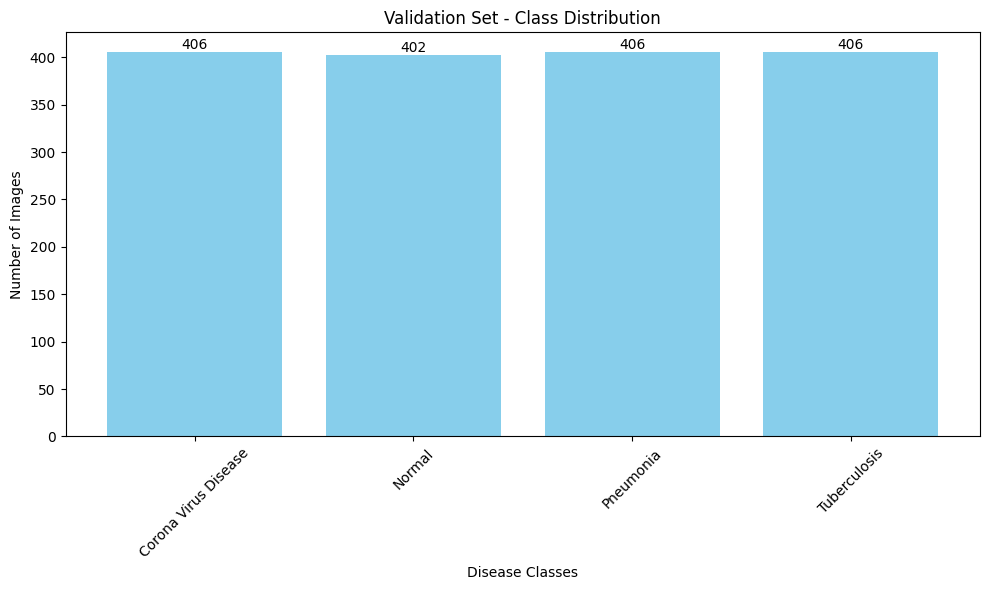


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


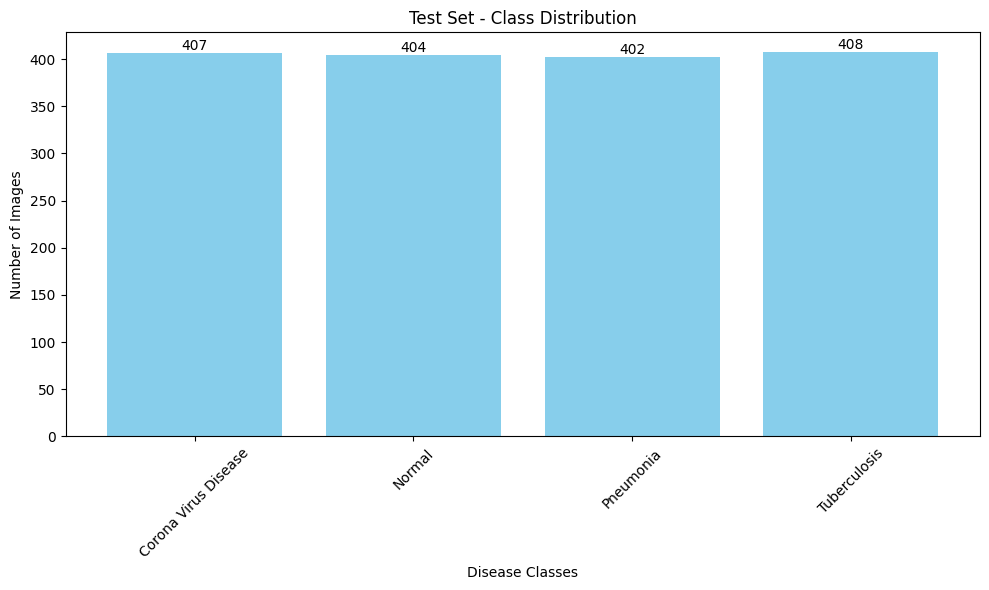

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
def load_datasets():
    """Load training, validation and test datasets"""
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [10]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")

Found 4846 files belonging to 4 classes.


I0000 00:00:1772298670.705088      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772298670.706540      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 303
📁 Validation batches: 102
📁 Test batches: 102


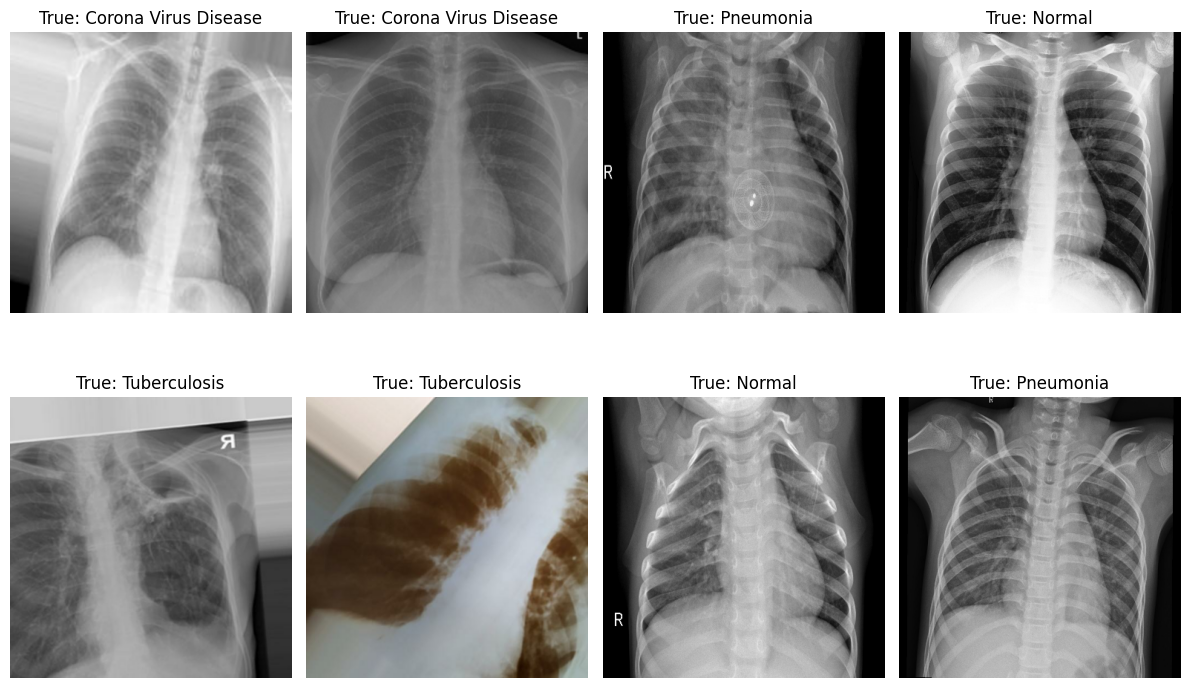

In [11]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [12]:
# -------------------------------
# Model Architecture - Transfer Learning with EfficientNetB4
# -------------------------------
def create_efficientnet_model():
    """Create transfer learning model with EfficientNetB4"""
    print(f"\n🛠️ Creating Transfer Learning Model with {CONFIG['base_model_name']}...")
    
    # Create base model with pre-trained weights
    base_model = tf.keras.applications.EfficientNetB4(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,  # Exclude the original classification head
        weights='imagenet',
        pooling='avg'  # GlobalAveragePooling2D
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    print(f"✅ Base model ({CONFIG['base_model_name']}) loaded with ImageNet weights")
    print(f"📊 Base model layers: {len(base_model.layers)}")
    print(f"🔒 Base model trainable: {base_model.trainable}")
    
    # Create custom classifier head
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Apply preprocessing (EfficientNet has built-in preprocessing)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    
    # Pass through base model
    x = base_model(x, training=False)
    
    # Add custom classifier with more capacity for EfficientNet features
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model

In [13]:
def compile_model(model, learning_rate):
    """Compile the model with optimizer, loss and metrics"""
    print(f"\n⚙️ Compiling Model with learning rate: {learning_rate}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [14]:
model, base_model = create_efficientnet_model()
model = compile_model(model, CONFIG['phase1_learning_rate'])


🛠️ Creating Transfer Learning Model with EfficientNetB4...
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model (EfficientNetB4) loaded with ImageNet weights
📊 Base model layers: 476
🔒 Base model trainable: False

⚙️ Compiling Model with learning rate: 0.001


In [15]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,836,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,173,155 (76.95 MB)

 Trainable params: 2,496,260 (9.52 MB)

 Non-trainable params: 17,676,895 (67.43 MB)

In [16]:
# -------------------------------
# Training Configuration
# -------------------------------
def get_phase1_callbacks():
    """Get callbacks for phase 1 (frozen base training)"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,  # More patience for EfficientNet
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-8,
            verbose=1
        ),
        
        # Save best model from phase 1
        tf.keras.callbacks.ModelCheckpoint(
            'efficientnet_phase1_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/efficientnet_phase1',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [17]:
phase1_callbacks = get_phase1_callbacks()

In [18]:
phase1_history = model.fit(
        training_set,
        epochs=CONFIG['phase1_epochs'],
        validation_data=validation_set,
        callbacks=phase1_callbacks,
        verbose=1
    )

Epoch 1/25


I0000 00:00:1772298701.704428      79 service.cc:148] XLA service 0x3b917d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772298701.705355      79 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772298701.705379      79 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772298705.874724      79 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1772298711.625527      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298711.807361      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1772298729.403787      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once fo

302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7359 - f1_score: 0.7354 - loss: 0.7962 - precision: 0.7537 - recall: 0.7143

E0000 00:00:1772298776.354818      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298776.530120      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7362 - f1_score: 0.7356 - loss: 0.7955 - precision: 0.7539 - recall: 0.7145

E0000 00:00:1772298819.783659      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298819.929493      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.91605, saving model to efficientnet_phase1_best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 155s 344ms/step - accuracy: 0.7364 - f1_score: 0.7359 - loss: 0.7947 - precision: 0.7541 - recall: 0.7148 - val_accuracy: 0.9160 - val_f1_score: 0.9156 - val_loss: 0.2386 - val_precision: 0.9187 - val_recall: 0.9142 - learning_rate: 0.0010
Epoch 2/25
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8661 - f1_score: 0.8661 - loss: 0.3965 - precision: 0.8736 - recall: 0.8600
Epoch 2: val_accuracy improved from 0.91605 to 0.93457, saving model to efficientnet_phase1_best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 70s 231ms/step - accuracy: 0.8661 - f1_score: 0.8661 - loss: 0.3964 - precision: 0.8736 - recall: 0.8600 - val_accuracy: 0.9346 - val_f1_score: 0.9344 - val_loss: 0.1862 - val_precision: 0.9356 - val_recall: 0.9327 - learning_rate: 0.0010
Epoch 3/25
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8924 - f1_score: 0.8926 - loss: 0.3

In [19]:
def get_phase2_callbacks():
    """Get callbacks for phase 2 (fine-tuning)"""
    callbacks = [
        # Early stopping with less patience for fine-tuning
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-9,  # Very low minimum LR for fine-tuning
            verbose=1
        ),
        
        # Save best model from phase 2
        tf.keras.callbacks.ModelCheckpoint(
            'efficientnet_phase2_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/efficientnet_phase2',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [20]:
 # Unfreeze the base model
base_model.trainable = True
    
# Fine-tune from this layer onwards (more conservative for EfficientNet)
fine_tune_at = int(len(base_model.layers) * 0.6)  # Fine-tune last 40% of layers
    
# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [21]:
# Recompile with much lower learning rate for fine-tuning EfficientNet
model = compile_model(model, CONFIG['phase2_learning_rate'])
    
phase2_callbacks = get_phase2_callbacks()


⚙️ Compiling Model with learning rate: 1e-05


In [22]:
print("🚀 Starting Phase 2 fine-tuning...")
phase2_history = model.fit(
        training_set,
        epochs=CONFIG['phase2_epochs'],
        validation_data=validation_set,
        callbacks=phase2_callbacks,
        verbose=1
    )

🚀 Starting Phase 2 fine-tuning...
Epoch 1/15


E0000 00:00:1772300554.851986      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300555.007224      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300555.532321      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300555.688612      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300556.007021      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8297 - f1_score: 0.8299 - loss: 0.6106 - precision: 0.8346 - recall: 0.8261

E0000 00:00:1772300675.105696      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300675.257243      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300675.739868      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300675.894668      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772300676.049915      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8298 - f1_score: 0.8301 - loss: 0.6102 - precision: 0.8348 - recall: 0.8262
Epoch 1: val_accuracy improved from -inf to 0.94444, saving model to efficientnet_phase2_best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 241s 527ms/step - accuracy: 0.8300 - f1_score: 0.8302 - loss: 0.6097 - precision: 0.8349 - recall: 0.8263 - val_accuracy: 0.9444 - val_f1_score: 0.9444 - val_loss: 0.1792 - val_precision: 0.9450 - val_recall: 0.9432 - learning_rate: 1.0000e-05
Epoch 2/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.8997 - f1_score: 0.8998 - loss: 0.3306 - precision: 0.9033 - recall: 0.8961
Epoch 2: val_accuracy improved from 0.94444 to 0.95370, saving model to efficientnet_phase2_best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 108s 356ms/step - accuracy: 0.8998 - f1_score: 0.8998 - loss: 0.3305 - precision: 0.9033 - recall: 0.8961 - val_accuracy: 0.9537 - val_f1_score: 0.9537 - val_loss: 0.1489 - val_precision: 0.9554 - val_recal

In [23]:
# Save the final model
model.save('efficientnetb4_final_model.h5')
model.save('efficientnetb4_final_model.keras')

In [24]:
# Save training history
with open('efficientnetb4_training_history.pkl', 'wb') as f:
        history_data = {
            'phase1': phase1_history.history,
            'phase2': phase2_history.history,
            'combined': {key: phase1_history.history[key] + phase2_history.history[key] 
                        for key in phase1_history.history.keys()},
            'config': CONFIG
        }
        pickle.dump(history_data, f)
    
print("✅ Final model saved as 'efficientnetb4_final_model.h5'")
print("✅ Training history saved as 'efficientnetb4_training_history.pkl'")

✅ Final model saved as 'efficientnetb4_final_model.h5'
✅ Training history saved as 'efficientnetb4_training_history.pkl'


# Model Evaluation

In [25]:
# -------------------------------
# Training Functions
# -------------------------------
def plot_combined_training_history(phase1_history, phase2_history):
    """Plot combined training history from both phases"""
    print("\n📈 Plotting Combined Training History...")
    
    # Combine histories
    combined_history = {}
    for key in phase1_history.history.keys():
        combined_history[key] = phase1_history.history[key] + phase2_history.history[key]
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Mark phase transition
    phase_transition = len(phase1_history.history['loss'])
    
    # Loss
    axes[0, 0].plot(combined_history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(combined_history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 1].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(combined_history['precision'], label='Training Precision', linewidth=2, color='blue')
    axes[0, 2].plot(combined_history['val_precision'], label='Validation Precision', linewidth=2, color='red')
    axes[0, 2].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 2].set_title('Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(combined_history['recall'], label='Training Recall', linewidth=2, color='blue')
    axes[1, 0].plot(combined_history['val_recall'], label='Validation Recall', linewidth=2, color='red')
    axes[1, 0].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 0].set_title('Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(combined_history['f1_score'], label='Training F1-Score', linewidth=2, color='blue')
    axes[1, 1].plot(combined_history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='red')
    axes[1, 1].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 1].set_title('Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in combined_history:
        axes[1, 2].plot(combined_history['lr'], label='Learning Rate', linewidth=2, color='purple')
        axes[1, 2].axvline(x=phase_transition, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training History - {CONFIG["base_model_name"]} (Phase 1: Frozen, Phase 2: Fine-tuning)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return combined_history


📈 Plotting Combined Training History...


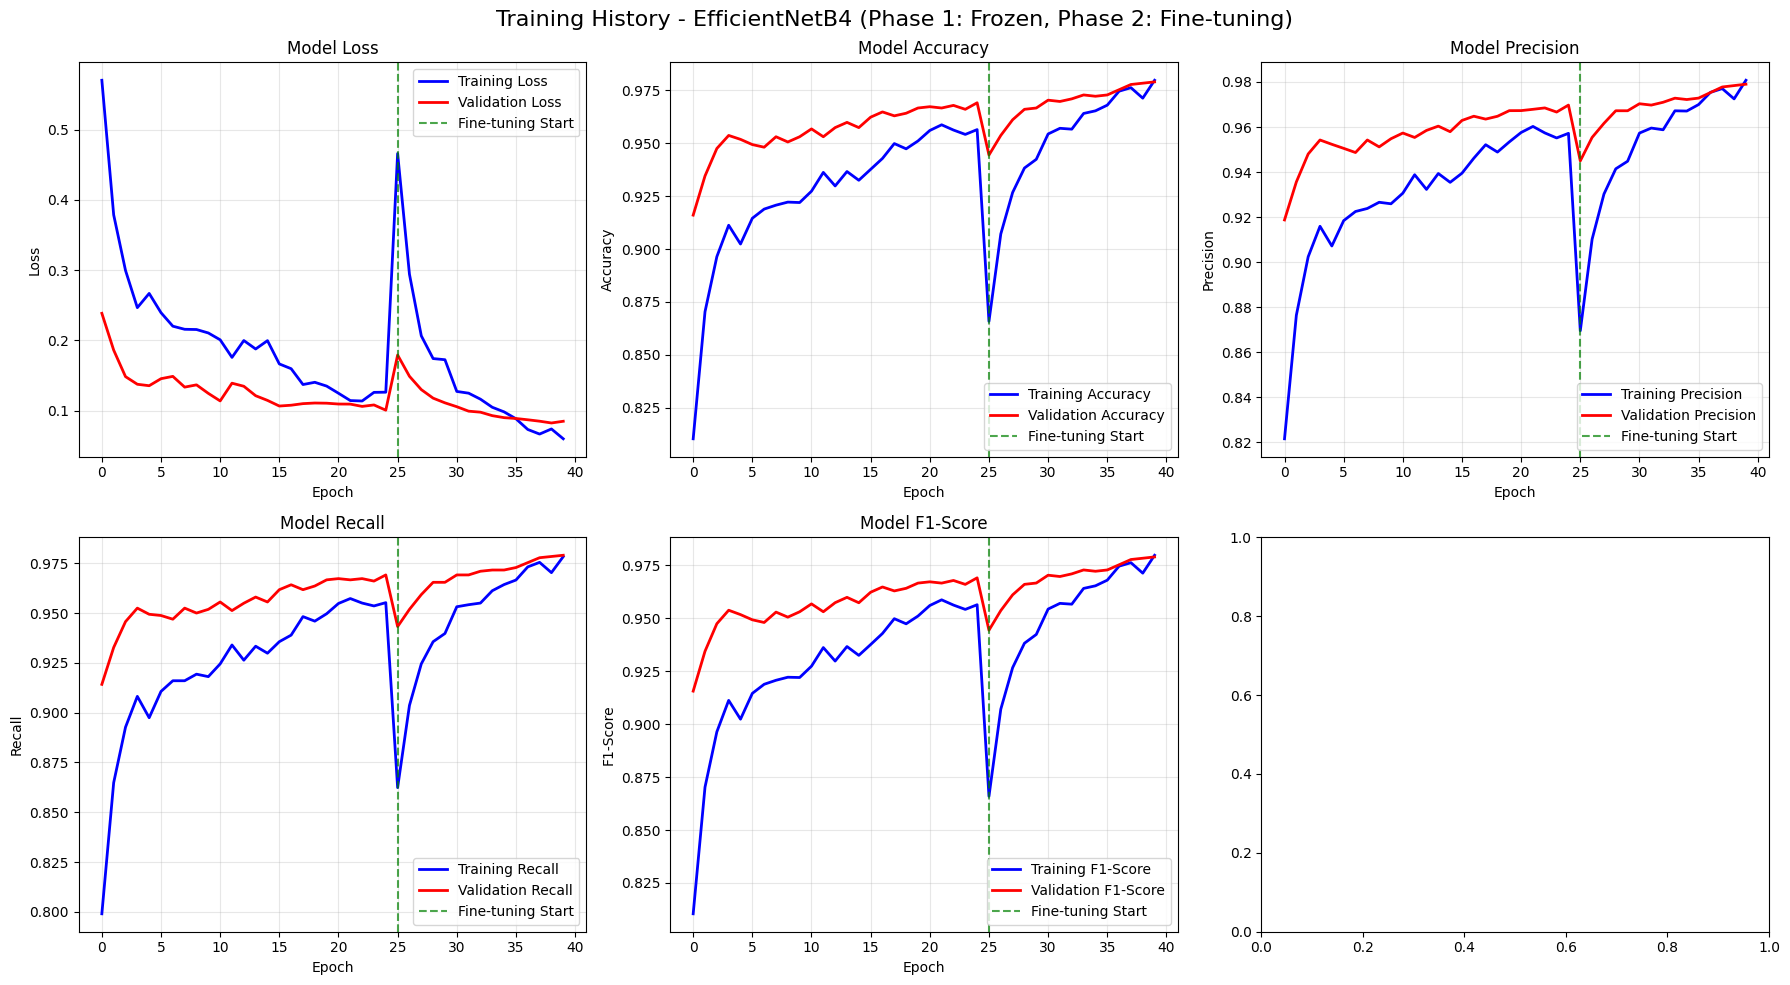

In [26]:
combined_history = plot_combined_training_history(phase1_history, phase2_history)

In [27]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_model(model, test_set, class_names):
    """Comprehensive model evaluation"""
    print("\n🧪 Evaluating Model Performance...")
    
    # Basic evaluation
    print("📊 Running Model Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Predictions...")
    y_true = []
    y_pred = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    return y_true, y_pred, eval_dict

In [28]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()


🧪 Evaluating Model Performance...
📊 Running Model Evaluation...
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9794 - f1_score: 0.9827 - loss: 0.0528 - precision: 0.9801 - recall: 0.9794

E0000 00:00:1772302268.039415      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772302268.189351      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step - accuracy: 0.9792 - f1_score: 0.9825 - loss: 0.0531 - precision: 0.9800 - recall: 0.9792

📋 Evaluation Results:
   Loss: 0.0684
   Accuracy: 0.9735
   Precision: 0.9741
   Recall: 0.9735
   F1_score: 0.9734

🔍 Generating Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       0.99      0.99      0.99       407
              Normal       0.94      0.98      0.96       404
           Pneumonia       0.98      0.93      0.95       402
        Tuberculosis       0.99      1.00      1.00       408

            accuracy                           0.97      1621
           macro avg       0.97      0.97      0.97      1621
        weighted avg       0.97      0.97      0.97      1621



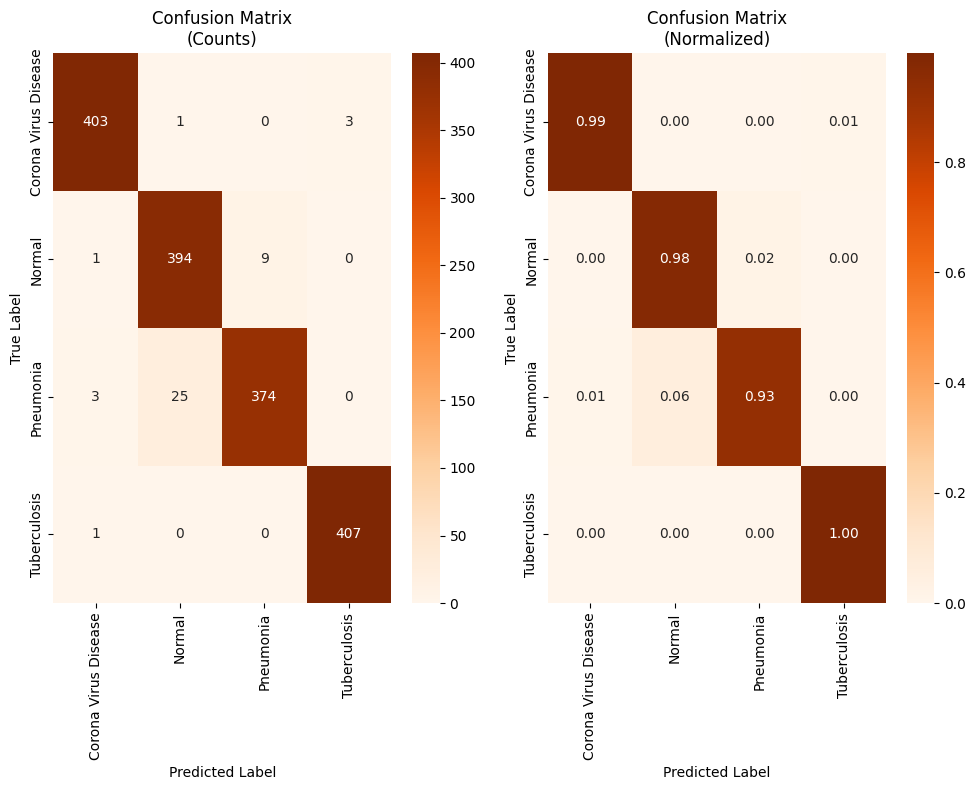

In [29]:
y_true, y_pred, eval_results = evaluate_model(model, test_set, class_names)

In [30]:
print("🎉 Transfer Learning with EfficientNetB4 Completed Successfully!")
print(f"📊 Final Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Final Test F1-Score: {eval_results['f1_score']:.2%}")

🎉 Transfer Learning with EfficientNetB4 Completed Successfully!
📊 Final Test Accuracy: 97.35%
📊 Final Test F1-Score: 97.34%


In [31]:
print(f"\n📈 Training Summary:")
print(f"   Phase 1 (Frozen): {len(phase1_history.history['loss'])} epochs")
print(f"   Phase 2 (Fine-tuned): {len(phase2_history.history['loss'])} epochs")
print(f"   Total Epochs: {len(phase1_history.history['loss']) + len(phase2_history.history['loss'])}")
print(f"   Final Learning Rate: {model.optimizer.learning_rate.numpy():.2e}")


📈 Training Summary:
   Phase 1 (Frozen): 25 epochs
   Phase 2 (Fine-tuned): 15 epochs
   Total Epochs: 40
   Final Learning Rate: 1.00e-05


In [32]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Tuberculosis/Tuberculosis-103.jpg"
img = tf.keras.utils.load_img(image_path, target_size=(224,224))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

(1, 224, 224, 3)

In [33]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Model Prediction:  Tuberculosis
